#Project in Pattern Recognition and Machine Learning
##kNN & PCA on the Dry Bean Dataset

## *Aleksandar Horvat i Dunja Tomašević*

# Obrada podataka i eksplorativna analiza

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_excel('Dry_Bean_Dataset.xlsx')


In [50]:
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


## Osnovne informacije

Kao deo standardne prakse proveravaju se osnovne informacije o skupu, nedostajuće vrednosti i duplikati.

In [51]:
df.shape

(13611, 17)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

## Nedostajuće vrednosti

In [53]:
missing = df.isnull().sum().sum()
print(missing)


0


## Duplikati

In [54]:
n_dup = df.duplicated().sum()
print(n_dup)

68


In [55]:
df = df.drop_duplicates()
print(df.shape)

(13543, 17)


## Deskriptivna statistika

In [56]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,13543.0,53048.460385,29392.438324,20420.000000,36282.500000,44580.000000,61382.000000,254616.000000
Perimeter,13543.0,854.993406,214.722684,524.736000,703.230000,793.896000,977.146500,1985.370000
MajorAxisLength,13543.0,319.895602,85.809260,183.601165,253.086806,296.404589,376.312489,738.860153
MinorAxisLength,13543.0,202.365321,45.051632,122.512653,175.886357,192.491117,217.245403,460.198497
AspectRation,13543.0,1.581075,0.245245,1.024868,1.430662,1.549860,1.703916,2.430306
Eccentricity,13543.0,0.750315,0.091858,0.218951,0.715144,0.763997,0.809671,0.911423
ConvexArea,13543.0,53767.986709,29844.248525,20684.000000,36673.000000,45122.000000,62360.000000,263261.000000
EquivDiameter,13543.0,253.034094,59.307709,161.243764,214.933277,238.245711,279.560351,569.374358
Extent,13543.0,0.749829,0.048939,0.555315,0.718735,0.759903,0.786849,0.866195
Solidity,13543.0,0.987152,0.004650,0.919246,0.985678,0.988288,0.990019,0.994677


Atributi imaju izrazito različite skale (`Area` u hiljadama, `Eccentricity` izmedju 0 i 1). Budući da kNN i weighted kNN  koriste
euklidsku udaljenost važno će biti date podatke standardizovati.

## Zastupljenost klasa

Nebalansiranost klasa direktno utice na kNN, kao i na weighted kNN, stoga je važno i ovo proveriti.

In [57]:
print(len(df['Class'].unique()))

7


In [58]:
class_counts = df['Class'].value_counts()
print(class_counts)


Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


In [59]:
print(f'Odnos najveće i najmanje klase: {class_counts.max() / class_counts.min():.1f}x')

Odnos najveće i najmanje klase: 6.8x


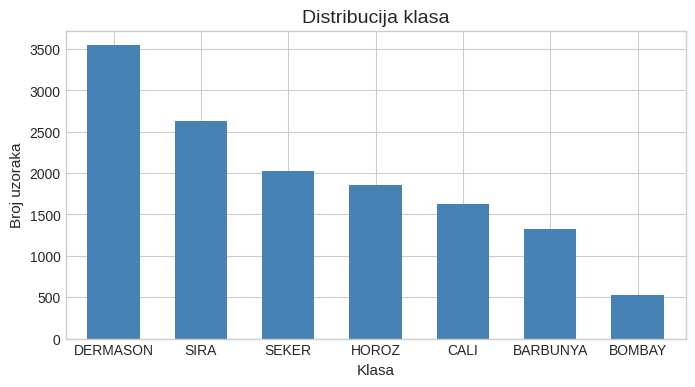

In [60]:
plt.figure(figsize=(8, 4))

plt.style.use('seaborn-v0_8-whitegrid') # ovako su lepsi malo grafici
class_counts.plot(kind='bar', color='#4682B4', width=0.6)

plt.title('Distribucija klasa', fontsize=14)
plt.xlabel('Klasa', fontsize=11)
plt.ylabel('Broj uzoraka', fontsize=11)
plt.xticks(rotation=0)

plt.show()


Skup nije savršeno balansiran, stoga ćemo pratiti i dodatne metrike pored tačnosti koje su naročito korisne u ovakvim slučajevima.

## Distribucija atributa

Raspodele atributa posmatramo jer PCA i kNN su osetljivi na ekstremne vrednosti. PCA formira kovarijansnu matricu, pa ako jedan uzorak ima neobično veliku vrednost, ta vrednost "navuče" varijansu ka sebi. kNN koristi euklidsku udaljenost, autlajer je *narušava* i kvari glasanje suseda. Zbog toga posmatramo da li distribucije imaju duge repove ili jako iskošen oblik.

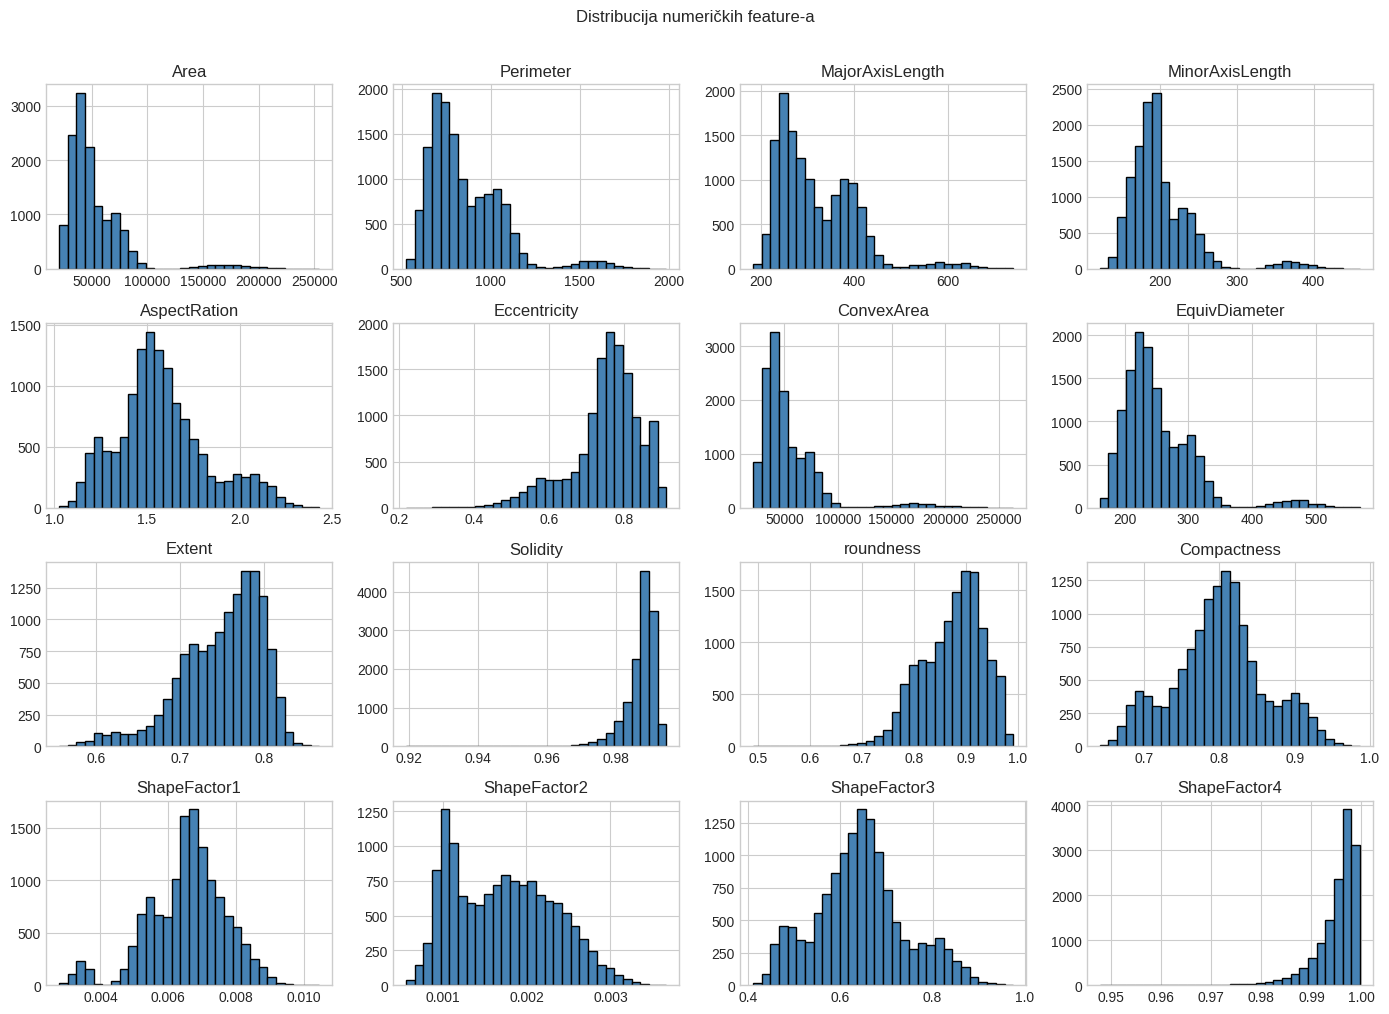

In [61]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
df[num_cols].hist(figsize=(14, 10), bins=30, edgecolor='black', color='steelblue')
plt.suptitle('Distribucija numeričkih feature-a', y=1.01)
plt.tight_layout()
plt.show()


Posmatrajući distribucije, uočavamo da atributi koji opisuju fizičke dimenzije zrna — `Area`, `Perimeter`, `MajorAxisLength`, `MinorAxisLength`, `ConvexArea` i `EquivDiameter` — pokazuju pozitivnu iskošenost sa dugačkim desnim repom. `AspectRation`, `Eccentricity` i `ShapeFactor2` pokazuju bimodalnu distribuciju sa dva vidljiva vrha. Relativno normalna raspodela je prisutna kod `Roundness`, `Compactness`, `ShapeFactor3`

Zbog iskošenosti prvonavedenih atributa, u nastavku ćemo uporediti dve verzije analize: jednu na originalnim standardizovanim podacima i jednu gde pre standardizacije primenimo log-transformaciju na pomenute feature-e kako bi se umanjio uticaj osobina datih distribucija.

## Korelaciona matrica

Zgodno je videti generalno matricu korelacije, pre nego što primenimo metodu redukcije dimenzionalnosti (PCA) koja zahteva korelisanost podataka.

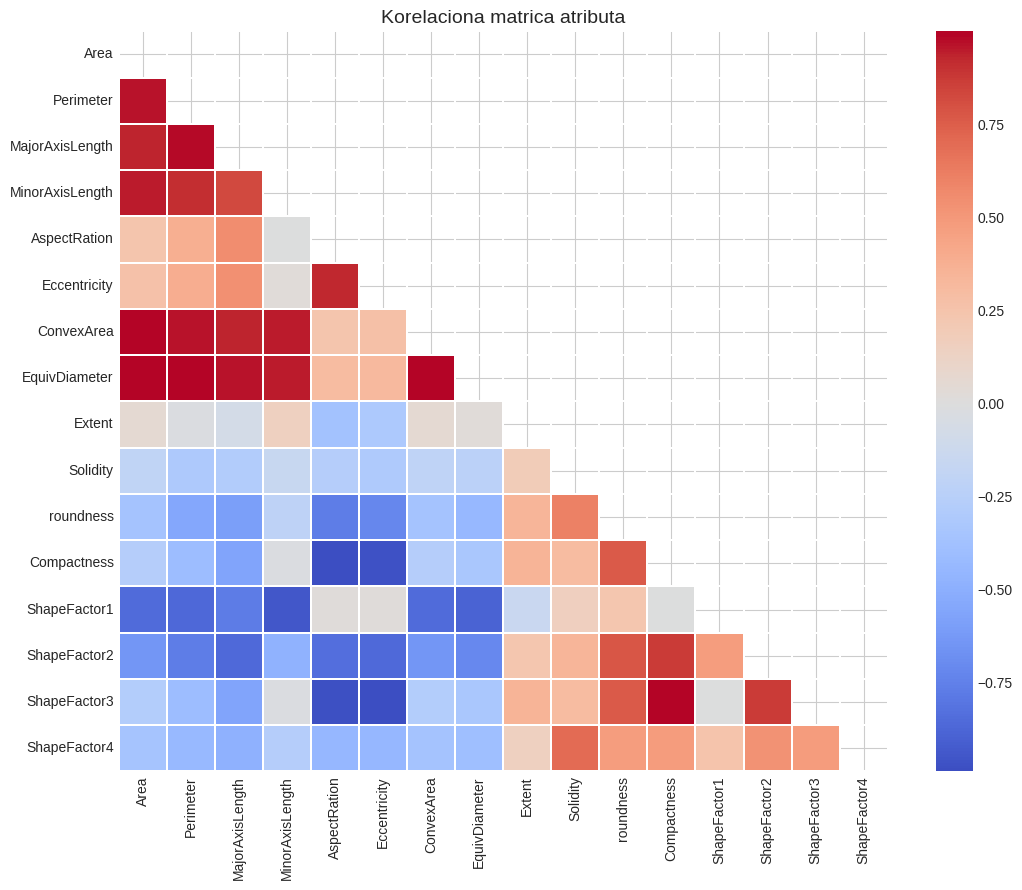

In [64]:
plt.figure(figsize=(11, 9))
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # prikazujemo samo donji trougao

sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm',
            center=0, linewidths=0.3)
plt.title('Korelaciona matrica atributa', fontsize=14)
plt.tight_layout()
plt.show()


Prva grupa — `Area`, `Perimeter`, `MajorAxisLength`, `MinorAxisLength`, `ConvexArea` i `EquivDiameter` — koji su međusobno jako pozitivno korelisani. Svi oni u suštini mere istu stvar: koliko je zrno veliko.

Druga uočljiva grupa su odličja oblika — `AspectRation`, `Eccentricity` i `ShapeFactor1` — koji su međusobno pozitivno korelisani, a negativno korelisani sa roundness, `Compactness` i `ShapeFactor2`. Ovo ima geometrijski smisao: izduženije zrno nužno ima manju okruglost.

`Extent` i `Solidity` se izdvajaju kao relativno nezavisni od ostalih atributa.

Ovakva struktura — dve jake grupe korelisanih feature-a plus nekoliko nezavisnih — je povoljna situacija za PCA i daje nam razlog da očekujemo da će mali broj komponenti objasniti veliki deo varijanse.

## Box plot atributa po klasama

 Prikazuje se box plot za svaki atribut sa klasama na x-osi, gde tačke van brkova predstavljaju stvarne autlajere unutar svake klase. Ova analiza je značajna i pored detekcije aulajera, za bolji prikaz raspona vrednosti atributa unutar klasa.

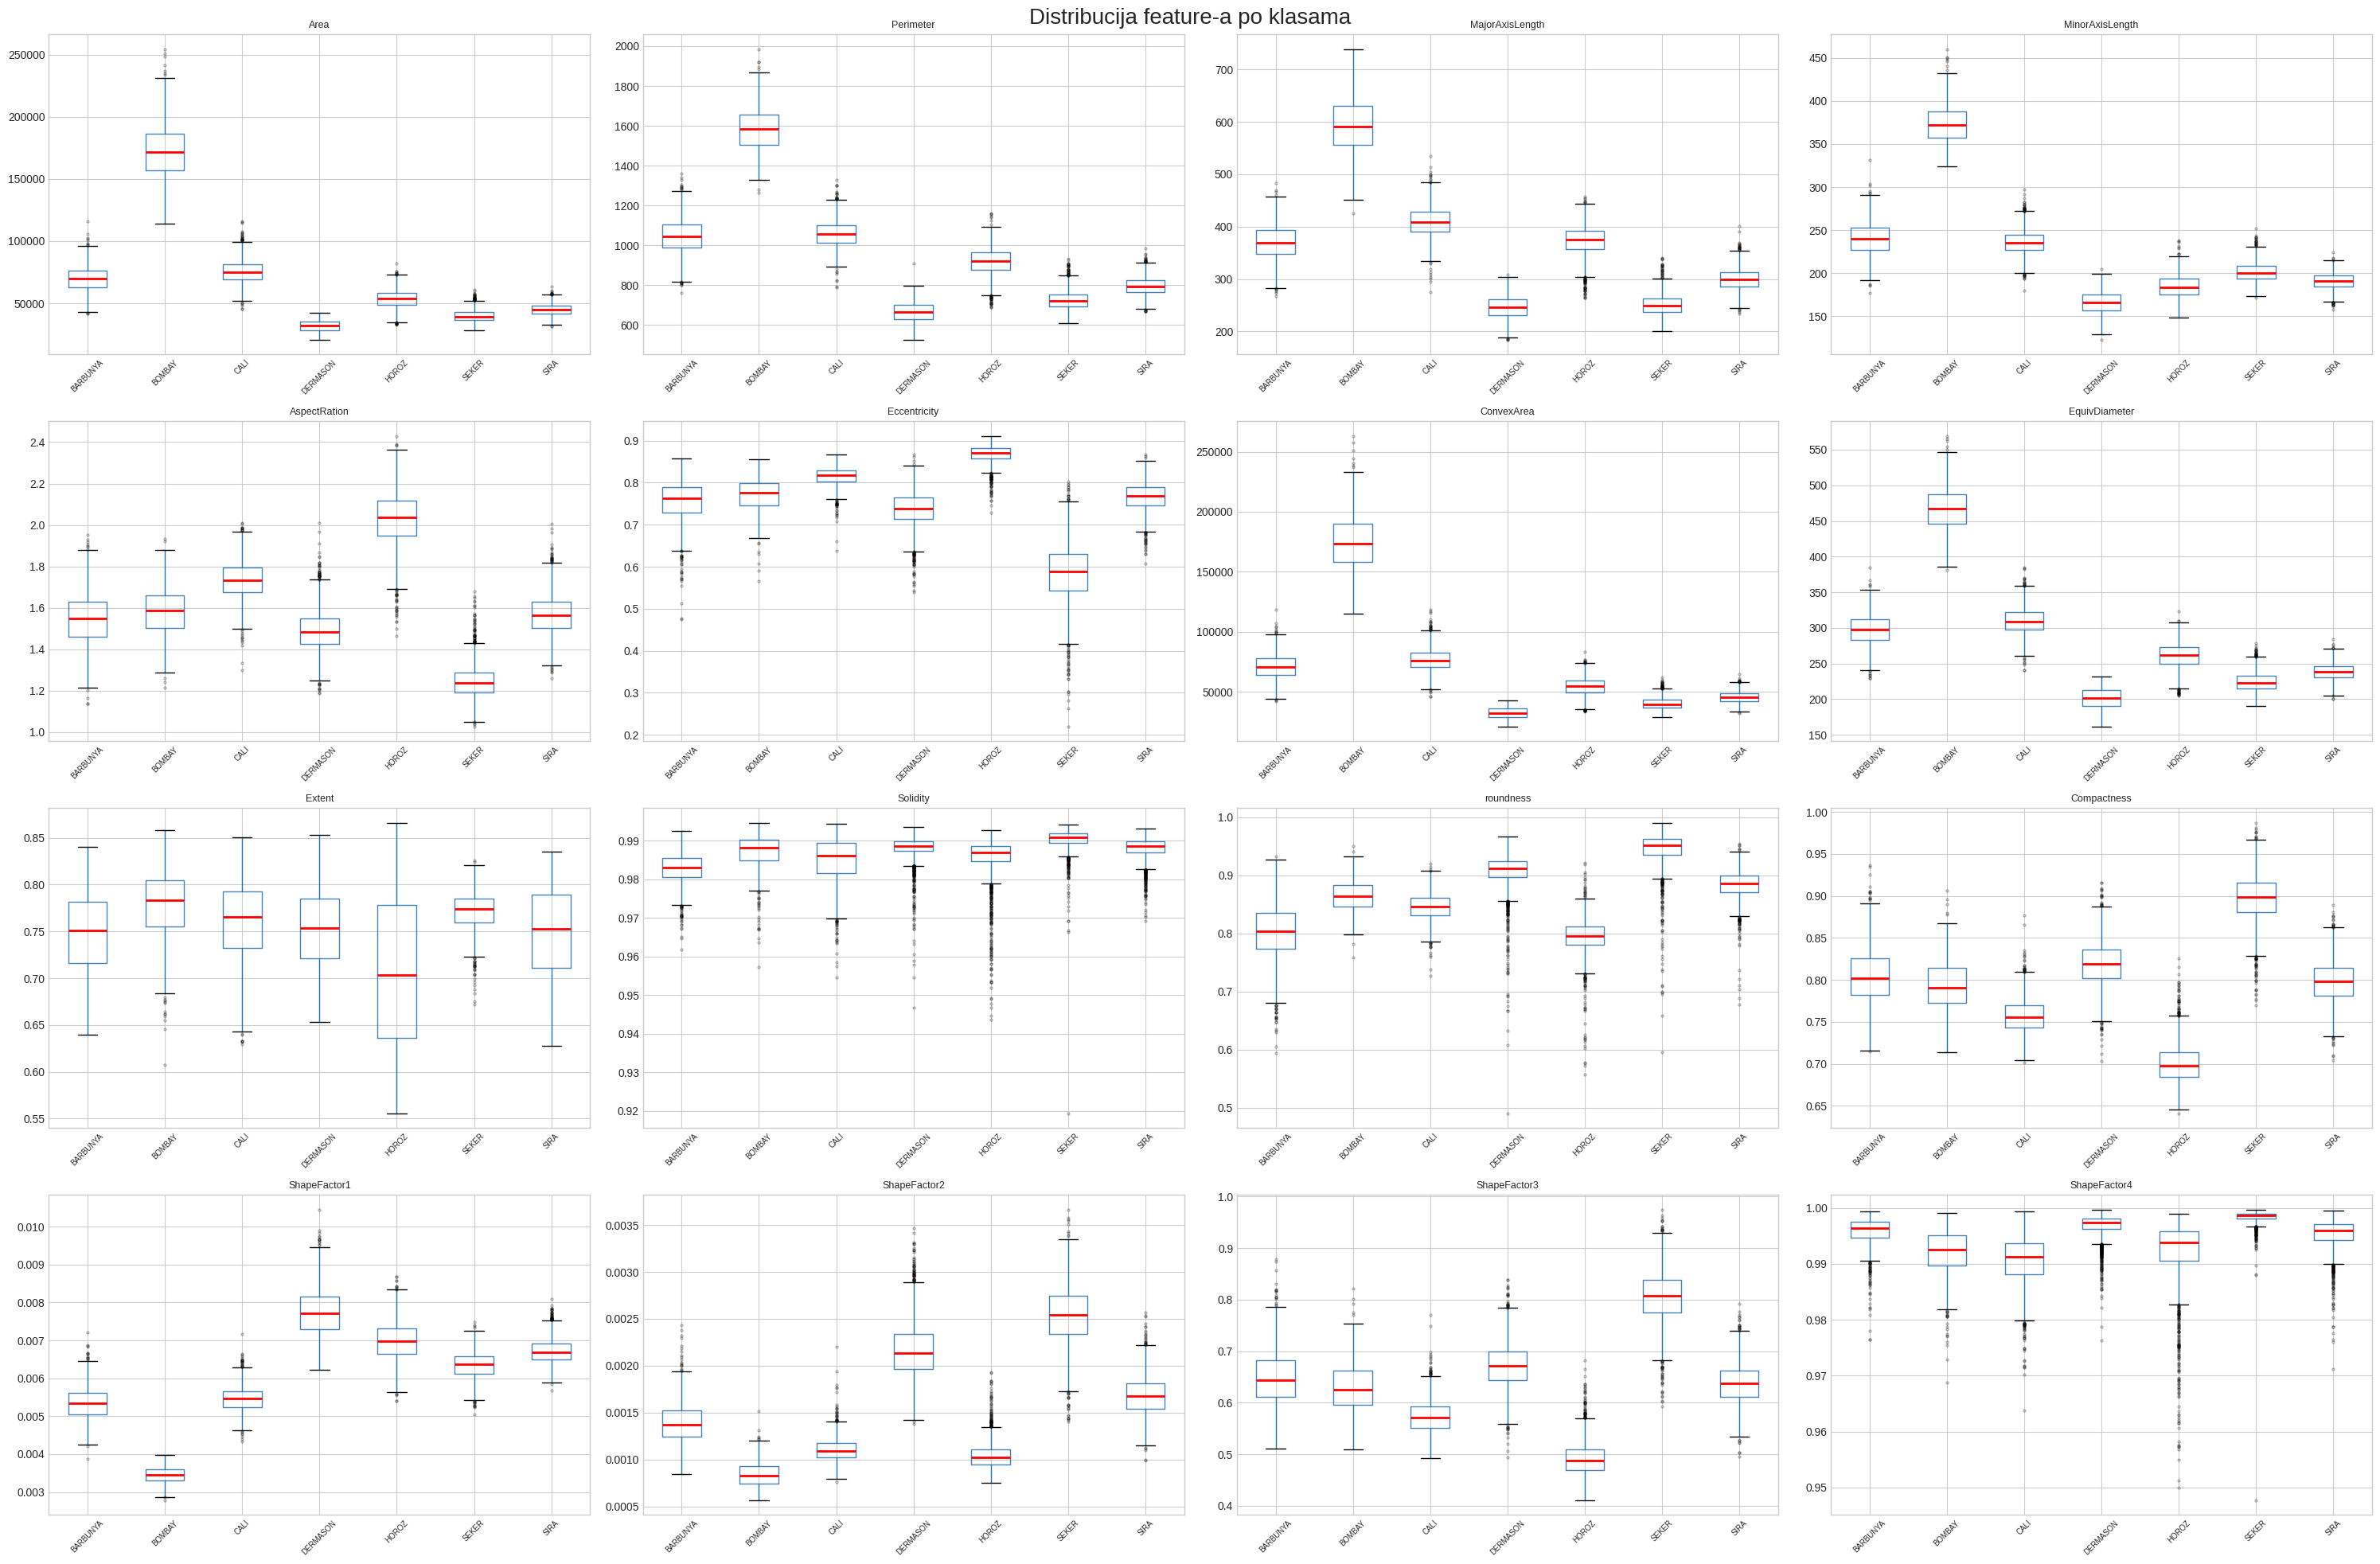

In [73]:
fig, axes = plt.subplots(4, 4, figsize=(30, 20))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='Class', ax=axes[i],
               boxprops=dict(color='#4682B4'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markersize=2, alpha=0.3, color='gray'))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', labelsize=7, rotation=45)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribucija feature-a po klasama', fontsize=20)
plt.tight_layout()
plt.show()

Bombay odskače kod dimenzijskih feature-a, ali unutar same klase nema puno autlajera. Extent je zanimljiv — Dermason ima enormno širok box u poređenju sa ostalima, što znači veliki varijabilitet unutar te klase. Solidity i ShapeFactor4 imaju duge brkove nadole kod skoro svih klasa — to su stvarni autlajeri unutar klasa, konzistentno kroz sve. Seker se jasno odvaja po Eccentricity i AspectRation — box je znatno niži od ostalih, što znači da ima okruglja zrna.

## Enkodiranje i priprema

In [65]:
le = LabelEncoder()
y = le.fit_transform(df['Class'])
X = df[num_cols].values
print('Klase:', le.classes_)
print('X shape:', X.shape, '| y shape:', y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# StandardScaler — jedna instanca za ceo notebook
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Train:', X_train_sc.shape, '| Test:', X_test_sc.shape)


Klase: ['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']
X shape: (13543, 16) | y shape: (13543,)
Train: (10834, 16) | Test: (2709, 16)


##Analiza srednjih vrednosti atributa po klasama

Kako bismo stekli uvid u to koliko su klase međusobno razdvojive u prostoru feature-a, posmatramo srednje vrednosti svakog feature-a po klasama nakon standardizacije.

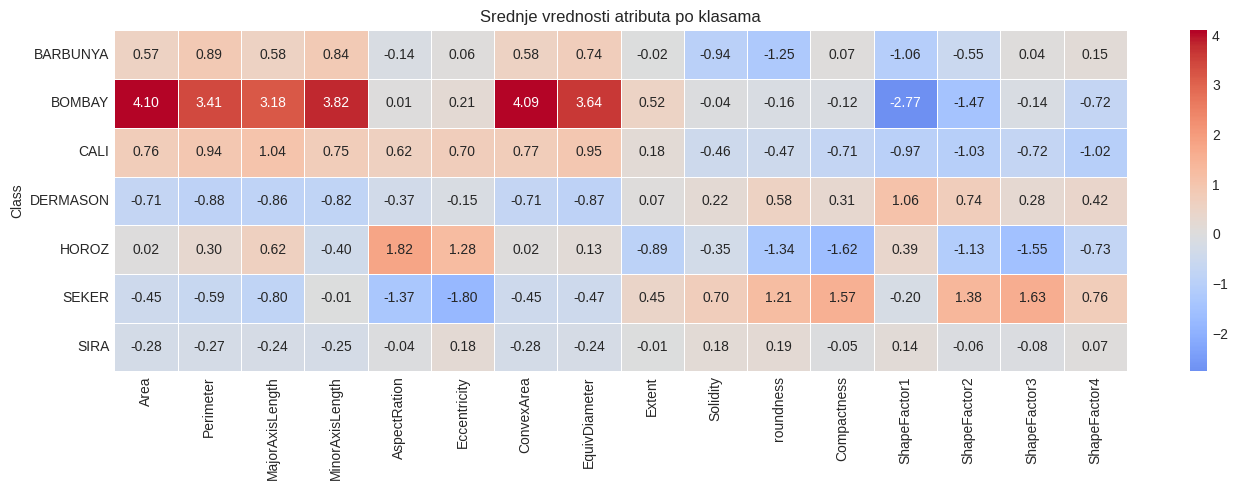

In [66]:
df_means = pd.DataFrame(X_train_sc, columns=num_cols)
df_means['Class'] = le.inverse_transform(y_train)
class_means = df_means.groupby('Class').mean()

plt.figure(figsize=(14, 5))
sns.heatmap(class_means, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.5)
plt.title('Srednje vrednosti atributa po klasama')
plt.tight_layout()
plt.show()

Heatmap otkriva da klase nisu podjednako razdvojive. Bombay se potpuno izdvaja, što sugeriše da će klasifikator tu klasu uspešno prepoznati. Sa druge strane, Barbunya i Cali, kao i Dermason i Sira pokazuju slične vrednosti za većinu feature-a, što ih čini najizazovnijim parom za klasifikaciju. Ovom analizom smo dobili uvid u potencijalne probleme daljeg rada na ovom skupu podataka.

# O sekciji

Na osnovu sprovedene eksplorativne analize može se zaključiti da je skup podataka sada spreman za dalju obradu. Analiza distribucija, korelacija i vrednosti po klasama dala je jasnu sliku strukture podataka: obeležja su grupisana u dve korelisane grupe što direktno motiviše primenu PCA, klase nisu podjednako razdvojive, što postavlja realna očekivanja od klasifikatora. Klasa Bombay se izdvaja kao odvojiva, dok su Barbunya, Cali, Dermason i Sira potencijalno problematični parovi. Sve ovo uzeto zajedno predstavlja osnovu za implementaciju i evaluaciju PCA i kNN algoritama u narednim sekcijama.